## Embedder

In [22]:
import os
import json
import pandas as pd
from backend.app.services.embedder import Embedder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [23]:
JSON_PATH = "/home/thehprogrammer/Projects/python/qa-method/data/json/"
openai_api_key = os.environ.get("OPENAI_API_KEY")

In [24]:
if not openai_api_key:
    raise ValueError("OPENAI_API_KEY não está definida nas variáveis de ambiente.")


In [48]:

# Lista para armazenar os dados
data = []

# Iterar sobre todos os arquivos JSON no diretório
for json_file in os.listdir(JSON_PATH):
    if json_file.endswith(".json"):
        json_path = os.path.join(JSON_PATH, json_file)
        
        # Carregar o conteúdo do JSON
        with open(json_path, "r", encoding="utf-8") as file:
            content = json.load(file)
        
        # Adicionar o conteúdo à lista de dados
        data.append(content)

In [49]:
# Criar um DataFrame a partir dos dados
df = pd.DataFrame(data)

# Garantir que a coluna "embedding" exista no DataFrame
df["embedding"] = None
df

,modalidade,autor,titulo,tipo,area_de_concentracao,ano_de_publicacao,local,orientador,coorientador,resumo,palavras_chave,abstract,keywords,introducao,conclusao,embedding
0,treino,Jorge Ivan Hmeljevski,Modelo para Sistemas de Supervisão de Mercado ...,tese,Engenharia do Conhecimento,2021,Florianópolis,"Prof. José Leomar Todesco, Dr.","Prof. Alexandre Leopoldo Gonçalves, Dr.",A confiança na higidez dos mercados de capitai...,"[Mercado de Capitais, Mercado de Valores Mobil...",The confidence in the integrity of capital mar...,"[Capital market, Securities Market, Market Sur...",{'contextualizacao': 'O mercado de capitais é ...,O modelo elaborado nest a pesquisa envolveu a ...,None
1,treino,IVAM GALVÃO FILHO,FRACTUS: APLICATIVO PARA APRENDIZAGEM DE FRAÇÕES,Dissertação,Engenharia do Conhecimento,2022,Florianópolis,"Profª. Vania Ribas Ulbricht, Drª.","Profª. Elisa Maria Pivetta, Drª.",O objetivo principal desta pesquisa foi o dese...,"[Objetos de Aprendizagem., Frações., Aplicativ...",The main objective of this research was the de...,"[Learning Objects., Fractions., App for Learni...",{'contextualizacao': 'O sistema educacional br...,O trabalho realizado pela organização TODOS PE...,None
2,treino,MÁRCIO CRESCENCIO,MODELO DE UMA REDE COLABORATIVA SUPORTADA POR ...,tese,Engenharia do Conhecimento,2022,Florianópolis,"Prof. Alexandre Augusto Biz , Dr.","Prof. José Leomar Todesco , Dr.",A convergência entre o turismo e a cultura atr...,"[Sítios de Patrimônio Mundial, Gestão do turis...",The convergence between tourism and culture th...,"[World Heritage Sites, Tourism management, Col...",{'contextualizacao': 'O turismo se tornou uma ...,Esta tese identificou que o turismo possui um ...,None
3,treino,Roseli Honorio,MODELO CONCEITUAL DE GOVERNANÇA DE DADOS COMO ...,Dissertação,Engenharia do Conhecimento,2022,Florianópolis,"Prof. João Artur de Souza, Dr.","Profa. Patrícia de Sá Freire, Dra.",A humanidade passou por transformações e revol...,"[Governança de Dados, Governança do Conhecimen...",Humanity has undergone transformations and rev...,"[Data Governance, Knowledge Governance, Framew...",{'contextualizacao': 'A sociedade está atraves...,"Na Ind ústria 4.0 e Sociedade 5.0, as organiza...",None
4,treino,José Tadeu Silva,Análise da contribuição da engenharia do conhe...,dissertação,Engenharia e Gestão do Conhecimento,2022,Florianópolis,"Prof. Fernando A. Ostuni Gauthier, Dr.","Prof. Marcelo Macedo, Dr.",A presente dissertação aborda as questões emer...,"[comércio eletrônico, modelo de análise, engen...",The present dissertation addresses the emergin...,"[e-commerce, analysis model, knowledge enginee...",{'contextualizacao': 'De acordo com Lemos (200...,A partir do objetivo geral de analisar as cont...,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,treino,Rosani Cesário Pereira,Competências essenciais dos pregoeiros: um est...,Dissertação,Gestão do Conhecimento,2023,Florianópolis,"Prof.a Édis Mafra Lapolli, Dr a.","Prof.a Gertrudes A. Dandolini , Dra.",O modelo de gestão que vem se consolidando na ...,"[competências, competências essenciais, pregoe...",The management model that has been consolidati...,"[competencies, essential competencies, public ...","{'contextualizacao': 'A autora, Rosani Cesário...",A pesquisa conclui que as competências essenci...,None
146,treino,Fabíola Provensi,Gestão do Conhecimento e Cultura de Segurança ...,dissertação,Gestão do Conhecimento,2023,Florianópolis,"Prof. Eduardo Juan Soriano Sierra, Dr.","Prof. Neri Dos Santos, Dr.","No âmbito deste estudo, no que tange à Cultura...","[gestão do conhecimento, cultura de segurança,...","In the scope of this study, regarding Safety C...","[knowledge management, safety culture, occupat...",{'contextualizacao': 'A Saúde e Segurança no T...,O estudo realizado foi enriquecedor e motivado...,None
147,treino,Maria Carolina Milani Caldas Sartor,Gestão feminina: a experiência de mulheres que...,tese,Gestão do Conhecimento,2023,Florianópolis,"Prof.a É

In [50]:
# Contar número por area_de_concentração e modalidade
counts = df.groupby(['area_de_concentracao', 'modalidade']).size().reset_index(name='counts')
counts

,area_de_concentracao,modalidade,counts
0,Engenharia do Conhecimento,teste,12
1,Engenharia do Conhecimento,treino,29
2,Engenharia e Gestão do Conhecimento,teste,3
3,Engenharia e Gestão do Conhecimento,treino,6
4,Gestão do Conhecimento,teste,15
5,Gestão do Conhecimento,treino,35
6,Mídia do Conhecimento,teste,15
7,Mídia do Conhecimento,treino,35


In [51]:
# Mostrar entidades do df que estão como "Engenharia e Gestão do Conhecimento"
df[df['area_de_concentracao'] == "Engenharia e Gestão do Conhecimento"]


,modalidade,autor,titulo,tipo,area_de_concentracao,ano_de_publicacao,local,orientador,coorientador,resumo,palavras_chave,abstract,keywords,introducao,conclusao,embedding
4,treino,José Tadeu Silva,Análise da contribuição da engenharia do conhe...,dissertação,Engenharia e Gestão do Conhecimento,2022,Florianópolis,"Prof. Fernando A. Ostuni Gauthier, Dr.","Prof. Marcelo Macedo, Dr.",A presente dissertação aborda as questões emer...,"[comércio eletrônico, modelo de análise, engen...",The present dissertation addresses the emergin...,"[e-commerce, analysis model, knowledge enginee...",{'contextualizacao': 'De acordo com Lemos (200...,A partir do objetivo geral de analisar as cont...,None
11,treino,Henrique Lopez Blanck,CAPITAL DE RISCO E STARTUPS: MODELO DE SUPORTE...,Dissertação,Engenharia e Gestão do Conhecimento,2020,Florianópolis,Prof. Dr. João Bosco da Mota Alves,Prof. Dr. João Artur de Souza,A Inovação transforma a relação entre pessoas ...,"[Capital de Risco, Tomada de decisão, Critério...",Innovation transforms the relationship between...,"[Venture capital, Decision making, Selection c...",{'contextualizacao': 'A velocidade da inovação...,Essa dissertação teve o objetivo de entender e...,None
19,treino,Milena Maredmi Corrêa Teixeira,Modelo de indicadores para avaliação e monitor...,Dissertação,Engenharia e Gestão do Conhecimento,2021,Florianópolis,Clarissa Stefani Teixeira,Gregório Jean Varvakis Rados,Nos ecossistemas de inovação é esperado que a ...,"[Centros de inovação, Indicadores, Habitats de...","In innovation ecosystems, the production of kn...","[Innovation Centers, Indicators, Innovation hu...",{'contextualizacao': 'A inovação não é apenas ...,O presente estudo buscou definir as informaçõe...,None
24,treino,"Vieira, Thaianne Fernanda dos Santos",MAPEAMENTO DOS CONHECIMENTOS CRÍTICOS PARA A I...,Dissertação,Engenharia e Gestão do Conhecimento,2022,Florianópolis,"Prof. Denilson Sell, Dr.",Prof. Gertrudes Dandolini,"O varejo passa por constantes transformações, ...","[Omnichannel, Varejo, Conhecimentos Críticos]","Retail goes through constant transformations, ...","[Omnichannel, Retail, Critical Knowledge]",{'contextualizacao': 'O varejo é uma área que ...,O trabalho contribui para a literatura científ...,None
30,teste,Rafael Maia Pinto,Detecção de erros e fraudes em gastos públicos...,Dissertação,Engenharia e Gestão do Conhecimento,2023,Florianópolis,"Profa. Lia Caetano Bastos, Dra.","Prof. Rogério Cid Bastos, Dr.",A Constituição Federal estabelece limites míni...,"[classificação de textos, lançamentos contábei...",The Brazilian Constitution establishes minimum...,[],{'contextualizacao': 'A Emenda Constitucional ...,À medida que a quantidade e complexidade das t...,None
31,teste,Elpídio Ribeiro Neves,Sistema sociotécnico de Integração de Modelos ...,Tese,Engenharia e Gestão do Conhecimento,2022,Florianópolis,"Prof. Paulo Maurício Selig, Dr.","Prof. Neri dos Santos, Dr.","As universidades, como organizações complexas,...","[Performance indicators, University evaluation...","Universities, as complex organizations, usuall...","[Performance indicators, University evaluation...",{'contextualizacao': 'Uma organização é mais q...,"Ao final deste trabalho, apresentam -se as con...",None
35,teste,Rangel Machado Simon,Educação digital superior: desenvolvendo as co...,Tese,Engenharia e Gestão do Conhecimento,2023,Florianópolis,"Fernando José Spanhol, Dr.","Márcio Vieira de Souza, Dr.",Este trabalho propõe um modelo conceitual de c...,"[Educação digital superior, Competência digita...",This study proposes a conceptual model of digi...,"[Digital higher education, Digital competence,...","{'contextualizacao': 'A evolução humana, impul...",A pesquisa evidenciou a necessidade de revisão...,None
44,treino,Douglas Alvares,APLICAÇÃO DE MÉTODOS DE ENGENHARIA DO CONHECIM...,Dissertação,Engenharia e Gestão do Conhecimento,2019,Florianópolis,Prof. Dr. Denilson Sell,,O processo de implantação de um software envol...,"[Implantação de Software

In [52]:
# Coluna tipo deixar tudo em minúsculo
df['tipo'] = df['tipo'].str.lower()
df.head()

,modalidade,autor,titulo,tipo,area_de_concentracao,ano_de_publicacao,local,orientador,coorientador,resumo,palavras_chave,abstract,keywords,introducao,conclusao,embedding
0,treino,Jorge Ivan Hmeljevski,Modelo para Sistemas de Supervisão de Mercado ...,tese,Engenharia do Conhecimento,2021,Florianópolis,"Prof. José Leomar Todesco, Dr.","Prof. Alexandre Leopoldo Gonçalves, Dr.",A confiança na higidez dos mercados de capitai...,"[Mercado de Capitais, Mercado de Valores Mobil...",The confidence in the integrity of capital mar...,"[Capital market, Securities Market, Market Sur...",{'contextualizacao': 'O mercado de capitais é ...,O modelo elaborado nest a pesquisa envolveu a ...,None
1,treino,IVAM GALVÃO FILHO,FRACTUS: APLICATIVO PARA APRENDIZAGEM DE FRAÇÕES,dissertação,Engenharia do Conhecimento,2022,Florianópolis,"Profª. Vania Ribas Ulbricht, Drª.","Profª. Elisa Maria Pivetta, Drª.",O objetivo principal desta pesquisa foi o dese...,"[Objetos de Aprendizagem., Frações., Aplicativ...",The main objective of this research was the de...,"[Learning Objects., Fractions., App for Learni...",{'contextualizacao': 'O sistema educacional br...,O trabalho realizado pela organização TODOS PE...,None
2,treino,MÁRCIO CRESCENCIO,MODELO DE UMA REDE COLABORATIVA SUPORTADA POR ...,tese,Engenharia do Conhecimento,2022,Florianópolis,"Prof. Alexandre Augusto Biz , Dr.","Prof. José Leomar Todesco , Dr.",A convergência entre o turismo e a cultura atr...,"[Sítios de Patrimônio Mundial, Gestão do turis...",The convergence between tourism and culture th...,"[World Heritage Sites, Tourism management, Col...",{'contextualizacao': 'O turismo se tornou uma ...,Esta tese identificou que o turismo possui um ...,None
3,treino,Roseli Honorio,MODELO CONCEITUAL DE GOVERNANÇA DE DADOS COMO ...,dissertação,Engenharia do Conhecimento,2022,Florianópolis,"Prof. João Artur de Souza, Dr.","Profa. Patrícia de Sá Freire, Dra.",A humanidade passou por transformações e revol...,"[Governança de Dados, Governança do Conhecimen...",Humanity has undergone transformations and rev...,"[Data Governance, Knowledge Governance, Framew...",{'contextualizacao': 'A sociedade está atraves...,"Na Ind ústria 4.0 e Sociedade 5.0, as organiza...",None
4,treino,José Tadeu Silva,Análise da contribuição da engenharia do conhe...,dissertação,Engenharia e Gestão do Conhecimento,2022,Florianópolis,"Prof. Fernando A. Ostuni Gauthier, Dr.","Prof. Marcelo Macedo, Dr.",A presente dissertação aborda as questões emer...,"[comércio eletrônico, modelo de análise, engen...",The present dissertation addresses the emergin...,"[e-commerce, analysis model, knowledge enginee...",{'contextualizacao': 'De acordo com Lemos (200...,A partir do objetivo geral de analisar as cont...,None


In [53]:
# Trocar "Engenharia e Gestão do Conhecimento" por "Engenharia do Conhecimento"
df['area_de_concentracao'] = df['area_de_concentracao'].replace("Engenharia e Gestão do Conhecimento", "Engenharia do Conhecimento")
counts = df.groupby(['area_de_concentracao', 'modalidade']).size().reset_index(name='counts')
counts

,area_de_concentracao,modalidade,counts
0,Engenharia do Conhecimento,teste,15
1,Engenharia do Conhecimento,treino,35
2,Gestão do Conhecimento,teste,15
3,Gestão do Conhecimento,treino,35
4,Mídia do Conhecimento,teste,15
5,Mídia do Conhecimento,treino,35


In [54]:
embedder = Embedder(api_key=openai_api_key)

In [32]:
# # Iterar sobre todos os arquivos JSON no diretório
# for json_file in os.listdir(JSON_PATH):
#     if json_file.endswith(".json"):
#         json_path = os.path.join(JSON_PATH, json_file)
        
#         # Carregar o conteúdo do JSON
#         with open(json_path, "r", encoding="utf-8") as file:
#             content = json.load(file)
        
#         # Remover a chave "embedding", se existir
#         if "embedding" in content:
#             del content["embedding"]
#             print(f'Removendo a chave "embedding" de {json_file}')
        
#             # Salvar o JSON atualizado de volta no arquivo
#             with open(json_path, "w", encoding="utf-8") as file:
#                 json.dump(content, file, ensure_ascii=False, indent=4)
#         else:
#             print(f'Chave "embedding" não encontrada em {json_file}')

Chave "embedding" não encontrada em PEGC0707-T.json
Chave "embedding" não encontrada em PEGC0718-D.json
Chave "embedding" não encontrada em PEGC0743-T.json
Chave "embedding" não encontrada em PEGC0739-D.json
Chave "embedding" não encontrada em PEGC0746-D.json
Chave "embedding" não encontrada em PEGC0679-D.json
Chave "embedding" não encontrada em PEGC0575-T.json
Chave "embedding" não encontrada em PEGC0619-D.json
Chave "embedding" não encontrada em PEGC0631-D.json
Chave "embedding" não encontrada em PEGC0643-T.json
Chave "embedding" não encontrada em PEGC0649-D.json
Chave "embedding" não encontrada em PEGC0651-D.json
Chave "embedding" não encontrada em PEGC0656-T.json
Chave "embedding" não encontrada em PEGC0663-T.json
Chave "embedding" não encontrada em PEGC0661-T.json
Chave "embedding" não encontrada em PEGC0665-D.json
Chave "embedding" não encontrada em PEGC0666-T.json
Chave "embedding" não encontrada em PEGC0678-T.json
Chave "embedding" não encontrada em PEGC0682-D.json
Chave "embed

In [55]:
def concat_fields(row):
    return (
        "Título: " + row["titulo"] + "\n" +
        "Área de concentração: " + row["area_de_concentracao"] + "\n" +
        "Resumo: " + row["resumo"] + "\n" +
        "Palavras-chave: " + ", ".join(row["palavras_chave"]) + "\n" +
        "Abstract: " + row["abstract"] + "\n" +
        "Keywords: " + ", ".join(row["keywords"]) + "\n" +
        "Introdução - Contextualização: " + row["introducao"]["contextualizacao"] + "\n" +
        "Introdução - Problematica: " + row["introducao"]["problematica"] + "\n" +
        "Introdução - Ineditismo: " + row["introducao"]["ineditismo"] + "\n" +
        "Introdução - Contribuição: " + row["introducao"]["contribuição"] + "\n" +
        "Conclusão: " + row["conclusao"]
    )

In [56]:
# Para cada linha do DataFrame, concatenar os campos, chamar o Embedder e salvar o embedding na coluna "embedding"
for index, row in df.iterrows():
    text = concat_fields(row)
    try:
        embedding = embedder.get_embedding(text)
        df.at[index, "embedding"] = embedding
    except Exception as e:
        print(f"Erro ao obter embedding para o arquivo {index}:")
        print(e)

In [57]:
# Retornar as linhas que tem embedding nulo
df[df["embedding"].isnull()]

,modalidade,autor,titulo,tipo,area_de_concentracao,ano_de_publicacao,local,orientador,coorientador,resumo,palavras_chave,abstract,keywords,introducao,conclusao,embedding


In [58]:
# Salvar em um arquivo CSV
df.to_csv("data.csv", index=False)

## PCA

In [59]:
pca = PCA(n_components=3)
df[['x', 'y', 'z']] = pd.DataFrame(pca.fit_transform(df['embedding'].tolist()), index=df.index)


In [60]:
df.head()

,modalidade,autor,titulo,tipo,area_de_concentracao,ano_de_publicacao,local,orientador,coorientador,resumo,palavras_chave,abstract,keywords,introducao,conclusao,embedding,x,y,z
0,treino,Jorge Ivan Hmeljevski,Modelo para Sistemas de Supervisão de Mercado ...,tese,Engenharia do Conhecimento,2021,Florianópolis,"Prof. José Leomar Todesco, Dr.","Prof. Alexandre Leopoldo Gonçalves, Dr.",A confiança na higidez dos mercados de capitai...,"[Mercado de Capitais, Mercado de Valores Mobil...",The confidence in the integrity of capital mar...,"[Capital market, Securities Market, Market Sur...",{'contextualizacao': 'O mercado de capitais é ...,O modelo elaborado nest a pesquisa envolveu a ...,"[0.02262425608932972, 0.06360490620136261, 0.0...",-0.174124,0.159395,-0.060768
1,treino,IVAM GALVÃO FILHO,FRACTUS: APLICATIVO PARA APRENDIZAGEM DE FRAÇÕES,dissertação,Engenharia do Conhecimento,2022,Florianópolis,"Profª. Vania Ribas Ulbricht, Drª.","Profª. Elisa Maria Pivetta, Drª.",O objetivo principal desta pesquisa foi o dese...,"[Objetos de Aprendizagem., Frações., Aplicativ...",The main objective of this research was the de...,"[Learning Objects., Fractions., App for Learni...",{'contextualizacao': 'O sistema educacional br...,O trabalho realizado pela organização TODOS PE...,"[-0.006245349999517202, 0.065089151263237, 0.0...",0.143998,0.263873,-0.055491
2,treino,MÁRCIO CRESCENCIO,MODELO DE UMA REDE COLABORATIVA SUPORTADA POR ...,tese,Engenharia do Conhecimento,2022,Florianópolis,"Prof. Alexandre Augusto Biz , Dr.","Prof. José Leomar Todesco , Dr.",A convergência entre o turismo e a cultura atr...,"[Sítios de Patrimônio Mundial, Gestão do turis...",The convergence between tourism and culture th...,"[World Heritage Sites, Tourism management, Col...",{'contextualizacao': 'O turismo se tornou uma ...,Esta tese identificou que o turismo possui um ...,"[0.024945586919784546, 0.04501194879412651, 0....",-0.111669,-0.167909,-0.015695
3,treino,Roseli Honorio,MODELO CONCEITUAL DE GOVERNANÇA DE DADOS COMO ...,dissertação,Engenharia do Conhecimento,2022,Florianópolis,"Prof. João Artur de Souza, Dr.","Profa. Patrícia de Sá Freire, Dra.",A humanidade passou por transformações e revol...,"[Governança de Dados, Governança do Conhecimen...",Humanity has undergone transformations and rev...,"[Data Governance, Knowledge Governance, Framew...",{'contextualizacao': 'A sociedade está atraves...,"Na Ind ústria 4.0 e Sociedade 5.0, as organiza...","[0.05032069981098175, 0.051356106996536255, 0....",-0.229669,0.045873,-0.059402
4,treino,José Tadeu Silva,Análise da contribuição da engenharia do conhe...,dissertação,Engenharia do Conhecimento,2022,Florianópolis,"Prof. Fernando A. Ostuni Gauthier, Dr.","Prof. Marcelo Macedo, Dr.",A presente dissertação aborda as questões emer...,"[comércio eletrônico, modelo de análise, engen...",The present dissertation addresses the emergin...,"[e-commerce, analysis model, knowledge enginee...",{'contextualizacao': 'De acordo com Lemos (200...,A partir do objetivo geral de analisar as cont...,"[-0.0012473083334043622, 0.044789645820856094,...",-0.195246,0.141014,0.098894


## Plot

/tmp/ipykernel_40883/3157379912.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_areas))


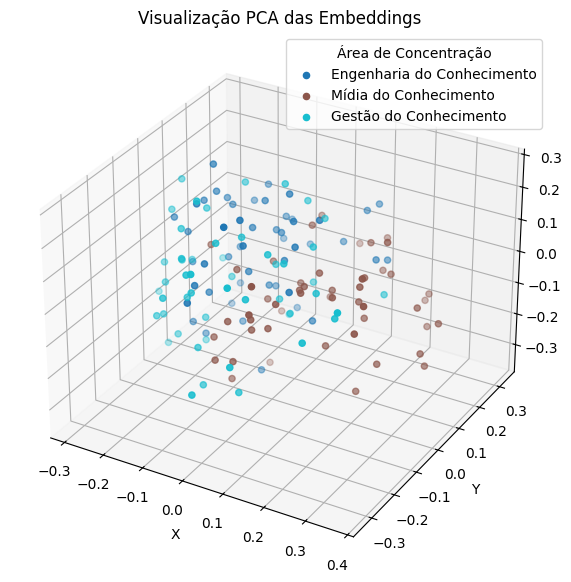

In [61]:
# Plotar as dimensões em um gráfico 3D com cores baseadas na área de concentração
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Definir um dicionário de cores para as áreas de concentração
unique_areas = df['area_de_concentracao'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_areas))
color_map = {area: colors(i) for i, area in enumerate(unique_areas)}

# Plotar os pontos com cores baseadas na área de concentração
for area in unique_areas:
    subset = df[df['area_de_concentracao'] == area]
    ax.scatter(subset['x'], subset['y'], subset['z'], label=area, color=color_map[area])

# Adicionar labels e título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Visualização PCA das Embeddings')

# Adicionar a legenda
ax.legend(title="Área de Concentração")

plt.show()

In [67]:
# Salvar csv e em hdf5
df.to_csv("data.csv", index=False)
df.to_hdf("data.h5", key='df', mode='w')

/tmp/ipykernel_40883/3390017757.py:3: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block1_values] [items->Index(['modalidade', 'autor', 'titulo', 'tipo', 'area_de_concentracao',
       'ano_de_publicacao', 'local', 'orientador', 'coorientador', 'resumo',
       'palavras_chave', 'abstract', 'keywords', 'introducao', 'conclusao',
       'embedding'],
      dtype='object')]

  df.to_hdf("data.h5", key='df', mode='w')
